# sklearn Pipeline - House Price Regression
## Train/Test Split → Baseline → Linear Regression → Random Forest → Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# load the processed feature matrix
X = pd.read_csv("../data/processed/X_features.csv")
y = pd.read_csv("../data/processed/y_target.csv")
y = y.squeeze()

print("X shape:", X.shape)
print("y shpae:", y.shape)
print("y dtype:", y.dtypes)

X shape: (2930, 90)
y shpae: (2930,)
y dtype: int64


In [2]:
# Train/test split — 80/20, stratify not needed for regression
# random_state=42 makes it reproducible (always do this)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Train target range: ${y_train.min():,.0f} – ${y_train.max():,.0f}")
print(f"Test  target range: ${y_test.min():,.0f} – ${y_test.max():,.0f}")

Train: 2344 samples
Test:  586 samples
Train target range: $12,789 – $755,000
Test  target range: $44,000 – $625,000


## Baseline Model Predict the mean for every house

In [3]:
# Baseline: predict mean of training set for every test sample
baseline_pred = np.full(len(y_test), y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print("=== BASELINE (predict mean) ===")
print(f"RMSE:  ${baseline_rmse:,.0f}")
print(f"MAE:   ${baseline_mae:,.0f}")
print(f"R²:    {baseline_r2:.4f}")
print()
print("Any real model must beat this.")

=== BASELINE (predict mean) ===
RMSE:  $90,222
MAE:   $64,611
R²:    -0.0153

Any real model must beat this.


## Model 1 - Linear Regression (sklearn Pipeline)

In [4]:
# Pipeline: scale features → linear regression
# StandardScaler is fitted ONLY on X_train - no leakage from test set
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_r2   = r2_score(y_test, lr_pred)

print("=== LINEAR REGRESSION ===")
print(f"RMSE:  ${lr_rmse:,.0f}  (baseline: ${baseline_rmse:,.0f})")
print(f"MAE:   ${lr_mae:,.0f}")
print(f"R²:    {lr_r2:.4f}")
print(f"\nImprovement over baseline: ${baseline_rmse - lr_rmse:,.0f} RMSE")

=== LINEAR REGRESSION ===
RMSE:  $32,260  (baseline: $90,222)
MAE:   $19,239
R²:    0.8702

Improvement over baseline: $57,963 RMSE


In [5]:
# Cross-validation - 5-fold, more reliable than single train/test split
lr_cv_scores = cross_val_score(
    lr_pipeline, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
lr_cv_rmse = -lr_cv_scores

print("5-Fold Cross-Validation RMSE:")
for i, score in enumerate(lr_cv_rmse, 1):
    print(f"  Fold {i}: ${score:,.0f}")
print(f"\nMean CV RMSE: ${lr_cv_rmse.mean():,.0f}")
print(f"Std  CV RMSE: ${lr_cv_rmse.std():,.0f}")

5-Fold Cross-Validation RMSE:
  Fold 1: $31,132
  Fold 2: $24,936
  Fold 3: $35,766
  Fold 4: $39,066
  Fold 5: $25,918

Mean CV RMSE: $31,364
Std  CV RMSE: $5,472


## Model 2 - Ridge Regression (regularized linear model)

In [6]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))# alpha controls regularization strength 
])
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
print("=== RIDGE REGRESSION (alpha=10) ===")
print(f"RMSE: ${ridge_rmse:,.0f}")
print(f"R²: {ridge_r2:.4f}") # Try different alpha values
alphas = [0.1, 1, 10, 100, 500]
print("\nalpha sweep:")
for a in alphas:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a)
    )])
    scores = -cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error")
    print(f" alpha={a:>5}: CV RMSE = ${scores.mean():,.0f}")

=== RIDGE REGRESSION (alpha=10) ===
RMSE: $32,228
R²: 0.8705

alpha sweep:
 alpha=  0.1: CV RMSE = $31,350
 alpha=    1: CV RMSE = $31,302
 alpha=   10: CV RMSE = $31,209
 alpha=  100: CV RMSE = $30,957
 alpha=  500: CV RMSE = $31,099


## Model 3 - Random Forest Regressor

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1 # use all CPU cores
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print("=== RANDOM FOREST ===")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"MAE: ${rf_mae:,.0f}")
print(f"R²: {rf_r2:.4f}")

=== RANDOM FOREST ===
RMSE: $25,438
MAE: $15,403
R²: 0.9193


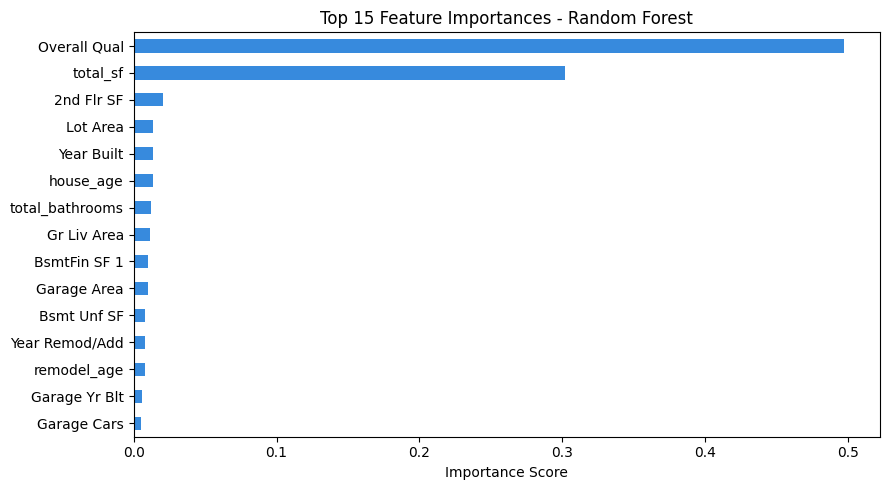


Top 5 features driving house price:
Overall Qual    0.497300
total_sf        0.301863
2nd Flr SF      0.020832
Lot Area        0.013788
Year Built      0.013653
dtype: float64


In [8]:
# Feature importance - which features the forest relied on most
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
top_features.plot(kind="barh", ax=ax, color="#378ADD")
ax.set_title("Top 15 Feature Importances - Random Forest") 
ax.set_xlabel("Importance Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../artifacts/feature_importance.png", dpi=150)
plt.show()
print("\nTop 5 features driving house price:") 
print(top_features.head())

## Model Comparison Summary

In [9]:
results = pd.DataFrame({
    "Model": ["Baseline (mean)", "Linear Regression", "Ridge (best alpha)", "Random Forest"],
    "RMSE ($)": [
        f"{baseline_rmse:,.0f}",
        f"{lr_rmse:,.0f}",
        f"{ridge_rmse:,.0f}",
        f"{rf_rmse:,.0f}",
    ],
    "R²": [
        f"{baseline_r2:.4f}",
        f"{lr_r2:.4f}",
        f"{ridge_r2:.4f}",
        f"{rf_r2:.4f}",
    ],
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

=== MODEL COMPARISON ===
             Model RMSE ($)      R²
   Baseline (mean)   90,222 -0.0153
 Linear Regression   32,260  0.8702
Ridge (best alpha)   32,228  0.8705
     Random Forest   25,438  0.9193


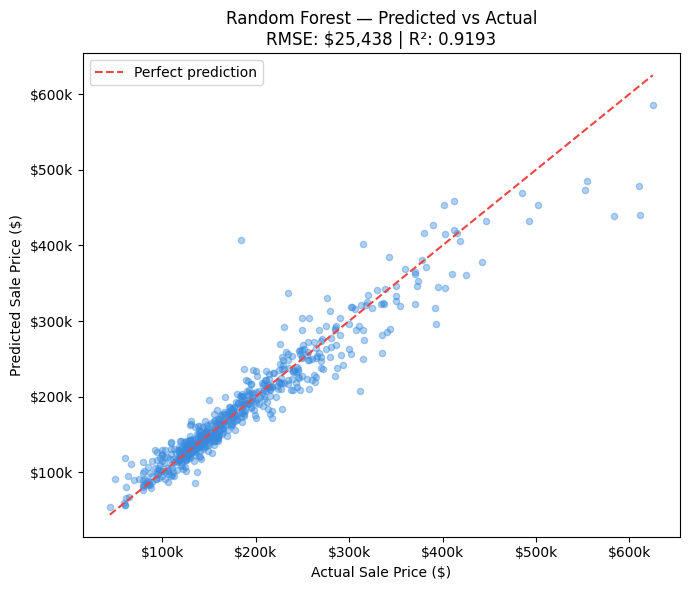

In [10]:
# Predicted vs Actual plot - visual proof the model works
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, rf_pred, alpha=0.4, color="#378ADD", s=20)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#EF4444", linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Sale Price ($)")
ax.set_ylabel("Predicted Sale Price ($)")
ax.set_title(f"Random Forest — Predicted vs Actual\nRMSE: ${rf_rmse:,.0f} | R²: {rf_r2:.4f}")
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
plt.tight_layout()
plt.savefig("../artifacts/predicted_vs_actual.png", dpi=150)
plt.show()

## Hyperparameter Tuning - GridSearchCV

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# Keep it focused — wide grids take hours on large datasets
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,         # shows progress
)

print("Starting grid search — this will take a few minutes...")
grid_search.fit(X_train, y_train)
print("Done.")

Starting grid search — this will take a few minutes...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Done.


In [12]:
# Results
print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV RMSE: ${-grid_search.best_score_:,.0f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print(f"\nTest set results (tuned model):")
print(f"  RMSE: ${best_rmse:,.0f}  (was ${rf_rmse:,.0f})")
print(f"  R²:   {best_r2:.4f}  (was {rf_r2:.4f})")
print(f"  Improvement: ${rf_rmse - best_rmse:,.0f} RMSE")

Best parameters:
  max_depth: None
  max_features: 0.5
  min_samples_leaf: 1
  n_estimators: 200

Best CV RMSE: $24,951

Test set results (tuned model):
  RMSE: $26,034  (was $25,438)
  R²:   0.9155  (was 0.9193)
  Improvement: $-596 RMSE


In [13]:
# Final comparison table - all models including tuned 
results_final = pd.DataFrame({ 
    "Model": [ "Baseline (mean)", "Linear Regression", "Ridge Regression", "Random Forest (default)", "Random Forest (tuned)", ], 
    "RMSE ($)": [ f"{baseline_rmse:,.0f}", f"{lr_rmse:,.0f}", f"{ridge_rmse:,.0f}", f"{rf_rmse:,.0f}", f"{best_rmse:,.0f}", ], 
    "R²": [ f"{baseline_r2:.4f}", f"{lr_r2:.4f}", f"{ridge_r2:.4f}", f"{rf_r2:.4f}", f"{best_r2:.4f}", ], 
})

print("=== FINAL MODEL COMPARISON ===")
print(results_final.to_string(index=False))

=== FINAL MODEL COMPARISON ===
                  Model RMSE ($)      R²
        Baseline (mean)   90,222 -0.0153
      Linear Regression   32,260  0.8702
       Ridge Regression   32,228  0.8705
Random Forest (default)   25,438  0.9193
  Random Forest (tuned)   26,034  0.9155


## Model Export - joblib

In [14]:
import joblib
import json
from pathlib import Path

# Save the tuned model
model_path = Path("../artifacts/rf_house_prices.joblib")
joblib.dump(best_rf, model_path)
print(f"Model saved: {model_path}")
print(f"File size: {model_path.stat().st_size / 1024:.1f} KB")

# Save model metadata alongside it — critical for reproducibility
metadata = {
    "model": "RandomForestRegressor",
    "best_params": grid_search.best_params_,
    "cv_rmse": round(-grid_search.best_score_, 2),
    "test_rmse": round(best_rmse, 2),
    "test_r2": round(best_r2, 4),
    "n_features": X_train.shape[1],
    "n_train_samples": X_train.shape[0],
    "feature_names": list(X.columns),
    "trained_on": "Ames Housing Dataset",
}

meta_path = Path("../artifacts/rf_house_prices_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved: {meta_path}")

Model saved: ../artifacts/rf_house_prices.joblib
File size: 40200.4 KB
Metadata saved: ../artifacts/rf_house_prices_metadata.json


In [15]:
# Verify the saved model loads and predicts correctly
loaded_model = joblib.load(model_path)
verify_pred = loaded_model.predict(X_test[:5])
original_pred = best_rf.predict(X_test[:5])

print("Verify saved model matches original:")
for i, (v, o) in enumerate(zip(verify_pred, original_pred)):
    match = "✓" if abs(v - o) < 0.01 else "✗"
    print(f"  Sample {i+1}: saved=${v:,.0f}  original=${o:,.0f}  {match}")

Verify saved model matches original:
  Sample 1: saved=$170,021  original=$170,021  ✓
  Sample 2: saved=$100,262  original=$100,262  ✓
  Sample 3: saved=$193,303  original=$193,303  ✓
  Sample 4: saved=$126,653  original=$126,653  ✓
  Sample 5: saved=$117,985  original=$117,985  ✓


## Verify src/features.py

In [16]:
import sys
sys.path.append("..") 
from src.features import build_feature_matrix 

X_check, y_check = build_feature_matrix("../data/raw/AmesHousing.csv")
print("X shape:", X_check.shape) 
print("y shape:", y_check.shape)
print("Missing values:", X_check.isnull().sum().sum())
print("✓ src/features.py works correctly" if X_check.shape == X.shape else "✗ shape mismatch — check the module")

X shape: (2930, 90)
y shape: (2930,)
Missing values: 0
✓ src/features.py works correctly
